This notebook uses the concept of encoder - decoder and self attention to make the machine translation task happen so lets dive into it from loading to cleaing to model building to evaluating to gradio app !

In [1]:
# importing the data from kaggle
# make sure you have kaggle.json file for your user profile
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d aiswaryaramachandran/hindienglish-corpora

Dataset URL: https://www.kaggle.com/datasets/aiswaryaramachandran/hindienglish-corpora
License(s): copyright-authors
100% 13.9M/13.9M [00:00<00:00, 53.0MB/s]



In [3]:
# unzziping the data
!unzip /content/hindienglish-corpora.zip

Archive:  /content/hindienglish-corpora.zip
  inflating: Hindi_English_Truncated_Corpus.csv  


In [73]:
# creating the dataframe
import pandas as pd
df = pd.read_csv("/content/Hindi_English_Truncated_Corpus.csv")

In [74]:
# first 5 lines
df.head()

,source,english_sentence,hindi_sentence
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,ted,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,indic2012,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


In [75]:
# last 5
df.tail()

,source,english_sentence,hindi_sentence
127602,indic2012,Examples of art deco construction can be found...,आर्ट डेको शैली के निर्माण मैरीन ड्राइव और ओवल ...
127603,ted,and put it in our cheeks.,और अपने गालों में डाल लेते हैं।
127604,tides,"As for the other derivatives of sulphur , the ...","जहां तक गंधक के अन्य उत्पादों का प्रश्न है , द..."
127605,tides,its complicated functioning is defined thus in...,Zरचना-प्रकिया को उसने एक पहेली में यों बांधा है .
127606,ted,They've just won four government contracts to ...,हाल ही में उन्हें सरकारी ठेका मिला है करीब सौ ...


In [76]:
# we do not need the source column
df.drop(columns='source',axis=1,inplace=True)

In [77]:
# inital healt checkup of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127607 entries, 0 to 127606
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   english_sentence  127605 non-null  object
 1   hindi_sentence    127607 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB


In [78]:
df.shape

(127607, 2)

In [79]:
df.isnull().sum()

,0
english_sentence,2
hindi_sentence,0


In [80]:
# remove those 2 null values
df.dropna(inplace=True)

In [81]:
df.duplicated().sum()

np.int64(2780)

In [82]:
# drop the duplicates as we have 1 lakh rows and we will use the only around 25-50k rows the hardware problem
df.drop_duplicates(inplace=True)

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124825 entries, 0 to 127606
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   english_sentence  124825 non-null  object
 1   hindi_sentence    124825 non-null  object
dtypes: object(2)
memory usage: 2.9+ MB


In [85]:
total = len(df['english_sentence'])
uniques = df['english_sentence'].value_counts()

print('actual are ',total)
print('unique are ',uniques.count())
print('difference is ',total-uniques.count())

actual are  124825
unique are  124317
difference is  508


In [86]:
# same for hindi
total = len(df['hindi_sentence'])
uniques = df['hindi_sentence'].value_counts()

print('actual are ',total)
print('unique are ',uniques.count())
print('difference is ',total-uniques.count())

actual are  124825
unique are  97662
difference is  27163


In [87]:
# checking any other bias
df.sample(10)

,english_sentence,hindi_sentence
124730,Measurement of global warming is done by a cli...,ग्लोबल वार्मिंग की गणना जिसमे कई तरह के जलवायु...
72302,Connecting links,संबंधित कड़ियाँ
121362,But they were not allowed to enter here and th...,पर उसकी सेना ने आगे बढ़ने से इनकार कर दिया और ...
36932,as an op-ed in The New York Times.,एक कमेंटरी करने के रूप में न्यूयॉर्क टाइम्स में।
107647,The proteins so manufactured ; many of which a...,इस प्रकार निर्मित पोटीन जिनमें से कुछ स्वयं उत...
98201,"Doctors , dentists , opticians and pharmacists","डाक्टरज़ , दन्त चिकित्सक , आप्टीशियनज़ ( चश्मे..."
99569,most elementary solution to a problem that was...,तरीके पर कार्य करने का था
117579,The cleft of the hoof should be narrow .,खुर की विदर को तंग होना चाहिए .
91893,some god magic(maujja),ईश्वरीय चमत्कार (मौअजज़ा)
49673,of some extremely intrepid men and women,जो कुछ अति वीर पुरुष एवं महिलाएँ


In [ ]:
# the data need to be clean properly

In [89]:
# creating some feature which will help in getting the relavant text
df['length_english_sentence'] = df['english_sentence'].apply(lambda x:len(x.split()))
df['length_hindi_sentence'] = df['hindi_sentence'].apply(lambda x:len(x.split()))

In [91]:
# lets take those sentences which have both greater than 12 word so that learning will be consistent
df = df[(df['length_english_sentence']>=12) & (df['length_hindi_sentence']>=12)]
df

,english_sentence,hindi_sentence,length_english_sentence,length_hindi_sentence
0,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...",12,14
5,The then Governor of Kashmir resisted transfer...,कश्मीर के तत्कालीन गवर्नर ने इस हस्तांतरण का व...,20,23
8,“”Global Warming“” refer to warming caused in ...,ग्लोबल वॉर्मिंग से आशय हाल ही के दशकों में हुई...,22,30
9,You may want your child to go to a school that...,हो सकता है कि आप चाहते हों कि आप का नऋर्नमेनटे...,34,39
14,The first two were found unreliable and the pr...,पहले दो को अविश्वसनीय मानकर बाकी पांच मुखबिरों...,21,15
...,...,...,...,...
127599,About 85 per cent of our tea production was di...,हमारे चाय उत्पादन का 85 प्रतिशत सीधे ब्रिटेन क...,38,28
127601,It is now widening its boundaries and it may i...,अब यह अपनी सीमाओं को फैला रहा है और हो सकता है...,45,60
127602,Examples of art deco construction can be found...,आर्ट डेको शैली के निर्माण मैरीन ड्राइव और ओवल ...,15,15
127604,"As for the other derivatives of sulphur , the ...","जहां तक गंधक के अन्य उत्पादों का प्रश्न है , द...",36,34


In [93]:
# finding the max and min of each hindi english sentence
def calculate_min_max(df, column_name):
    min_value = df[column_name].min()
    max_value = df[column_name].max()
    return min_value, max_value

min_length_english, max_length_english = calculate_min_max(df, 'length_english_sentence')
min_length_hindi, max_length_hindi = calculate_min_max(df, 'length_hindi_sentence')

print(f"Minimum length in 'english_sentence': {min_length_english}")
print(f"Maximum length in 'english_sentence': {max_length_english}")

print(f"Minimum length in 'hindi_sentence': {min_length_hindi}")
print(f"Maximum length in 'hindi_sentence': {max_length_hindi}")

Minimum length in 'english_sentence': 12
Maximum length in 'english_sentence': 398
Minimum length in 'hindi_sentence': 12
Maximum length in 'hindi_sentence': 418


In [100]:
df.reset_index(inplace=True,drop=True)
df

,english_sentence,hindi_sentence,length_english_sentence,length_hindi_sentence
0,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...",12,14
1,The then Governor of Kashmir resisted transfer...,कश्मीर के तत्कालीन गवर्नर ने इस हस्तांतरण का व...,20,23
2,“”Global Warming“” refer to warming caused in ...,ग्लोबल वॉर्मिंग से आशय हाल ही के दशकों में हुई...,22,30
3,You may want your child to go to a school that...,हो सकता है कि आप चाहते हों कि आप का नऋर्नमेनटे...,34,39
4,The first two were found unreliable and the pr...,पहले दो को अविश्वसनीय मानकर बाकी पांच मुखबिरों...,21,15
...,...,...,...,...
63008,About 85 per cent of our tea production was di...,हमारे चाय उत्पादन का 85 प्रतिशत सीधे ब्रिटेन क...,38,28
63009,It is now widening its boundaries and it may i...,अब यह अपनी सीमाओं को फैला रहा है और हो सकता है...,45,60
63010,Examples of art deco construction can be found...,आर्ट डेको शैली के निर्माण मैरीन ड्राइव और ओवल ...,15,15
63011,"As for the other derivatives of sulphur , the ...","जहां तक गंधक के अन्य उत्पादों का प्रश्न है , द...",36,34


In [101]:
df.shape

(63013, 4)

In [102]:
# since now we had removed the inital bias so we can extract some random 30k rows
df = df.sample(40000,random_state=2)

In [103]:
df.shape

(40000, 4)

In [104]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [105]:
# word tokenisation
# remember we are doing enlish to hindi not hindi to english

In [106]:
# importing all preprocessing libraries and toolkit
import re
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [108]:
# look up dictonary to convert short english word to full word cannot neglect the stop words here
lookup_dict = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so is",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
}

In [116]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [119]:
# cleanining english and hindi seaprately

def clean_english(text):
    text = str(text).lower().strip()

    # Remove text inside parentheses like (Laughter), (Applause)
    text = re.sub(r"\(.*?\)", "", text)

    words = text.split()
    expanded_words = [lookup_dict.get(word, word) for word in words]
    text = " ".join(expanded_words)

    #Standardize punctuation spacing
    text = re.sub(r"([.!?])", r" \1 ", text)

    # Strip out non-alphabetic characters (numbers, special symbols)
    text = re.sub(r"[^a-zA-Z.!?]+", r" ", text)

    # Final tokenization
    final_tokens = word_tokenize(text)

    return final_tokens

In [120]:
df['english_sentence'] = df['english_sentence'].apply(lambda x:clean_english(x))
df

,english_sentence,hindi_sentence,length_english_sentence,length_hindi_sentence
52350,"[q, some, say, you, were, the, one, who, explo...",> कुछ लग कहते हैं कि आपने उस मित्रता को भुनाया .,13,12
1196,"[a, scheme, for, balancing, and, optimisation,...",सुविधाओं के संतुलित तथा सर्वोत्तम उपयोग की योज...,12,14
5286,"[with, her, is, a, young, man, husband, brothe...","उसके साथ एक युवक भी है - पति, भाई, प्रेमी - मु...",14,14
13419,"[the, adhishthana, as, also, the, outer, wall,...",अधिष्ठान भी और उसके ऊपर की बाहरी दीवार भी अंतर...,57,53
21861,"[some, nationalised, banks, too, are, shedding...","यही नहीं , कुछ सरकारी बैंक भी अपनी रूढिवादी छव...",24,20
...,...,...,...,...
13826,"[when, these, words, of, the, former, leeds, u...",-जॉर्ज ग्राहम जब लीड़्स युनाइटेड़ और आर्सेनल फ...,45,46
46136,"[black, marketeers, and, profiteers, have, rea...",काला बाजार करने वालों और मुनाफाखोरों ने अपनी अ...,19,25
45634,"[from, hume, he, received, constant, encourage...",ह्रयूम से उनऋ-ऊण्श्छ्ष्-हें निरंतर हर तरह का प...,46,40
38857,"[avoid, taking, your, child, on, holiday, at, ...",परीक्षा या टैस्ट के समय बच्चे को अपने साथ ले ज...,19,16


In [121]:
def clean_hindi(text):
    # Ensure text is string and convert to lowercase
    text = str(text).lower().strip()

    # Remove common translation artifacts like "(Laughter)" or "(Applause)" if present in text
    text = re.sub(r"\(.*?\)", "", text)

    # Isolate Hindi punctuation marks like the Poorna विराम (।) and standard sentence endings
    text = re.sub(r"([।.!?])", r" \1 ", text)

    # Keep only Devnagari characters, spaces, and basic sentence punctuation
    # This strips out stray English text, digits, and unwanted mathematical symbols
    text = re.sub(r"[^\u0900-\u097F।.!?\s]+", r" ", text)

    # Tokenize by splitting spaces
    words = text.split()

    return words

In [122]:
df['hindi_sentence'] = df['hindi_sentence'].apply(lambda x:clean_hindi(x))
df

,english_sentence,hindi_sentence,length_english_sentence,length_hindi_sentence
52350,"[q, some, say, you, were, the, one, who, explo...","[कुछ, लग, कहते, हैं, कि, आपने, उस, मित्रता, को...",13,12
1196,"[a, scheme, for, balancing, and, optimisation,...","[सुविधाओं, के, संतुलित, तथा, सर्वोत्तम, उपयोग,...",12,14
5286,"[with, her, is, a, young, man, husband, brothe...","[उसके, साथ, एक, युवक, भी, है, पति, भाई, प्रेमी...",14,14
13419,"[the, adhishthana, as, also, the, outer, wall,...","[अधिष्ठान, भी, और, उसके, ऊपर, की, बाहरी, दीवार...",57,53
21861,"[some, nationalised, banks, too, are, shedding...","[यही, नहीं, कुछ, सरकारी, बैंक, भी, अपनी, रूढिव...",24,20
...,...,...,...,...
13826,"[when, these, words, of, the, former, leeds, u...","[जॉर्ज, ग्राहम, जब, लीड़्स, युनाइटेड़, और, आर्...",45,46
46136,"[black, marketeers, and, profiteers, have, rea...","[काला, बाजार, करने, वालों, और, मुनाफाखोरों, ने...",19,25
45634,"[from, hume, he, received, constant, encourage...","[ह्रयूम, से, उनऋ, ऊण्श्छ्ष्, हें, निरंतर, हर, ...",46,40
38857,"[avoid, taking, your, child, on, holiday, at, ...","[परीक्षा, या, टैस्ट, के, समय, बच्चे, को, अपने,...",19,16


In [124]:
df.reset_index(drop=True,inplace=True)

In [126]:
df.shape

(40000, 4)

In [127]:
df

,english_sentence,hindi_sentence,length_english_sentence,length_hindi_sentence
0,"[q, some, say, you, were, the, one, who, explo...","[कुछ, लग, कहते, हैं, कि, आपने, उस, मित्रता, को...",13,12
1,"[a, scheme, for, balancing, and, optimisation,...","[सुविधाओं, के, संतुलित, तथा, सर्वोत्तम, उपयोग,...",12,14
2,"[with, her, is, a, young, man, husband, brothe...","[उसके, साथ, एक, युवक, भी, है, पति, भाई, प्रेमी...",14,14
3,"[the, adhishthana, as, also, the, outer, wall,...","[अधिष्ठान, भी, और, उसके, ऊपर, की, बाहरी, दीवार...",57,53
4,"[some, nationalised, banks, too, are, shedding...","[यही, नहीं, कुछ, सरकारी, बैंक, भी, अपनी, रूढिव...",24,20
...,...,...,...,...
39995,"[when, these, words, of, the, former, leeds, u...","[जॉर्ज, ग्राहम, जब, लीड़्स, युनाइटेड़, और, आर्...",45,46
39996,"[black, marketeers, and, profiteers, have, rea...","[काला, बाजार, करने, वालों, और, मुनाफाखोरों, ने...",19,25
39997,"[from, hume, he, received, constant, encourage...","[ह्रयूम, से, उनऋ, ऊण्श्छ्ष्, हें, निरंतर, हर, ...",46,40
39998,"[avoid, taking, your, child, on, holiday, at, ...","[परीक्षा, या, टैस्ट, के, समय, बच्चे, को, अपने,...",19,16


In [128]:
# lets make this more consitent words between 12 and 30 words only so max will also be restricted
df = df[(df['length_english_sentence']>=12) & (df['length_english_sentence']<=30)]

In [131]:
df.shape

(26950, 4)

In [135]:
df.drop(columns=['length_english_sentence','length_hindi_sentence'],axis=1,inplace=True)

In [136]:
df

,english_sentence,hindi_sentence
0,"[q, some, say, you, were, the, one, who, explo...","[कुछ, लग, कहते, हैं, कि, आपने, उस, मित्रता, को..."
1,"[a, scheme, for, balancing, and, optimisation,...","[सुविधाओं, के, संतुलित, तथा, सर्वोत्तम, उपयोग,..."
2,"[with, her, is, a, young, man, husband, brothe...","[उसके, साथ, एक, युवक, भी, है, पति, भाई, प्रेमी..."
3,"[some, nationalised, banks, too, are, shedding...","[यही, नहीं, कुछ, सरकारी, बैंक, भी, अपनी, रूढिव..."
4,"[tadunter, king, shalya, became, the, chief, o...","[तदनन्तर, राजा, शल्य, कौरव, सेना, के, सेनापति,..."
...,...,...
26945,"[roy, also, wanted, to, write, a, social, hist...","[राय, भारतीयों, का, पूर्व, वैदिक, काल, से, आधु..."
26946,"[hindus, and, muslims, know, islam, is, the, v...","[हिंदू, और, मुसलमान, दोनों, जानते, हैं, कि, इस..."
26947,"[the, trading, standards, department, can, als...","[ट्रेडिंग, स्टैंडर्डज़, डिपार्टमेंट, उस, व्यक्..."
26948,"[black, marketeers, and, profiteers, have, rea...","[काला, बाजार, करने, वालों, और, मुनाफाखोरों, ने..."


In [140]:
# separating x , y and train test
x = df['english_sentence']
y = df['hindi_sentence']

y = y.apply(lambda tokens: ['<START_>'] + tokens + ['<_END>'])

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [141]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((21560,), (5390,), (21560,), (5390,))

In [145]:
x[0] , y[0]

(['q',
  'some',
  'say',
  'you',
  'were',
  'the',
  'one',
  'who',
  'exploited',
  'the',
  'friendship',
  '.'],
 ['<START_>',
  'कुछ',
  'लग',
  'कहते',
  'हैं',
  'कि',
  'आपने',
  'उस',
  'मित्रता',
  'को',
  'भुनाया',
  '.',
  '<_END>'])

In [147]:
# tokenisation + padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# initialize
english_tokenizer = Tokenizer(filters='')
hindi_tokenizer = Tokenizer(filters='')

# fit on train data
english_tokenizer.fit_on_texts(X_train)
hindi_tokenizer.fit_on_texts(y_train)

# convert text tokens into sequence for train
X_train_seq = english_tokenizer.texts_to_sequences(X_train)
y_train_seq = hindi_tokenizer.texts_to_sequences(y_train)

# convert text tokens into sequence for test
X_test_seq = english_tokenizer.texts_to_sequences(X_test)
y_test_seq = hindi_tokenizer.texts_to_sequences(y_test)

In [149]:
max_eng_len = max(len(seq) for seq in X_train_seq)
max_hin_len = max(len(seq) for seq in y_train_seq)

In [156]:
# now padding
X_train_pad = pad_sequences(X_train_seq,maxlen=max_eng_len,padding='post',truncating='post')
y_train_pad = pad_sequences(y_train_seq,maxlen=max_hin_len,padding='post',truncating='post')

X_test_pad = pad_sequences(X_test_seq,maxlen=max_eng_len,padding='post',truncating='post')
y_test_pad = pad_sequences(y_test_seq,maxlen=max_hin_len,padding='post',truncating='post')

# vocabulary size
eng_vocab_size = len(english_tokenizer.word_index) + 1
hin_vocab_size = len(hindi_tokenizer.word_index) + 1

In [151]:
print(eng_vocab_size)
print(hin_vocab_size)

27033
29482


In [152]:
X_train_pad[0]

array([2459,  320,  726,   37, 1514,  690,    3, 7879,  235,   72,   18,
        568,   24,  924,    2,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0], dtype=int32)

Encoder - decoder architecture with attention

In [153]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Attention , Input , Concatenate
from tensorflow.keras.models import Model

# hyperparameters
embedding_dim = 256
latent_dim = 512

In [154]:
class Model:
  def __init__(self,eng_vocab_size,hin_vocab_size,embedding_dim,latent_dim,batch_size):
    self.eng_vocab_size = eng_vocab_size
    self.hin_vocab_size = hin_vocab_size
    self.embedding_dim = embedding_dim
    self.latent_dim = latent_dim
    self.batch_size = batch_size

  def build_encoder(self):
    self.encoder_inputs = Input(shape=(max_eng_len,),name='encoder_input')
    self.encoder_embedding = Embedding(self.eng_vocab_size,self.embedding_dim,mask_zero=True,name='encoder_embedding')(self.encoder_inputs)
    self.encoder_lstm = LSTM(self.latent_dim,return_sequences=True,return_state=True,name='encoder_lstm')
    self.encoder_outputs,state_h,state_c = self.encoder_lstm(self.encoder_embedding)
    self.encoder_states = [state_h,state_c]

  def build_decoder(self):
    self.decoder_inputs = Input(shape=(max_hin_len-1,),name='decoder_input')
    self.decoder_embedding = Embedding(self.hin_vocab_size,self.embedding_dim,mask_zero=True,name='decoder_embedding')(self.decoder_inputs)
    self.decoder_lstm = LSTM(self.latent_dim,return_sequences=True,return_state=True,name='decoder_lstm')
    self.decoder_outputs,_,_ = self.decoder_lstm(self.decoder_embedding,initial_state=self.encoder_states)
    self.decoder_attention = Attention(name='decoder_attention')
    self.context_vector = self.decoder_attention([self.decoder_outputs,self.encoder_outputs])
    self.decoder_concat = Concatenate(axis=-1,name='decoder_concat')([self.decoder_outputs,self.context_vector])

  def output(self):
    self.decoder_dense = Dense(self.hin_vocab_size,activation='softmax',name='decoder_output')
    self.output = self.decoder_dense(self.decoder_concat)
    self.model = Model(inputs=[self.encoder_inputs,self.decoder_inputs],outputs=self.output)
    return self.model

In [159]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Decoder Input: contains <sos> up to the second to last word
decoder_input_data = y_train_pad[:, :-1]

# Decoder Target: contains everything after <sos> up to <eos>
decoder_target_data = y_train_pad[:, 1:]

# Do the same for test/validation data
decoder_input_test = y_test_pad[:, :-1]
decoder_target_test = y_test_pad[:, 1:]

# Instantiate the model
model_instance = Model(eng_vocab_size, hin_vocab_size, embedding_dim, latent_dim, batch_size=64) # batch_size for Model class isn't used for training here
model_instance.build_encoder()
model_instance.build_decoder()

# Explicitly create the final output layer and model from Keras functional API
final_decoder_dense = tf.keras.layers.Dense(hin_vocab_size, activation='softmax', name='decoder_output')
model = tf.keras.models.Model(inputs=[model_instance.encoder_inputs, model_instance.decoder_inputs],
                              outputs=final_decoder_dense(model_instance.decoder_concat))

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_hindi_nmt_model.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    x=[X_train_pad, decoder_input_data],
    y=decoder_target_data,
    validation_data=([X_test_pad, decoder_input_test], decoder_target_test),
    batch_size=64,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 181s 513ms/step - accuracy: 0.1556 - loss: 6.4511 - val_accuracy: 0.1957 - val_loss: 5.7084
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 179s 531ms/step - accuracy: 0.2087 - loss: 5.5712 - val_accuracy: 0.2311 - val_loss: 5.2769
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 178s 529ms/step - accuracy: 0.2479 - loss: 4.9579 - val_accuracy: 0.2563 - val_loss: 4.9111
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 182s 541ms/step - accuracy: 0.2912 - loss: 4.3304 - val_accuracy: 0.2811 - val_loss: 4.6579
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 184s 548ms/step - accuracy: 0.3419 - loss: 3.7251 - val_accuracy: 0.3025 - val_loss: 4.5018
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 184s 546ms/step - accuracy: 0.4064 - loss: 3.1697 - val_accuracy: 0.3218 - val_loss: 4.4122
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 187s 555ms/step - accuracy: 0.4752 - loss: 2.6823 - val_accuracy: 0.3346 - val_loss: 4.3834
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 189s 561ms/step - accuracy: 0.5392 -

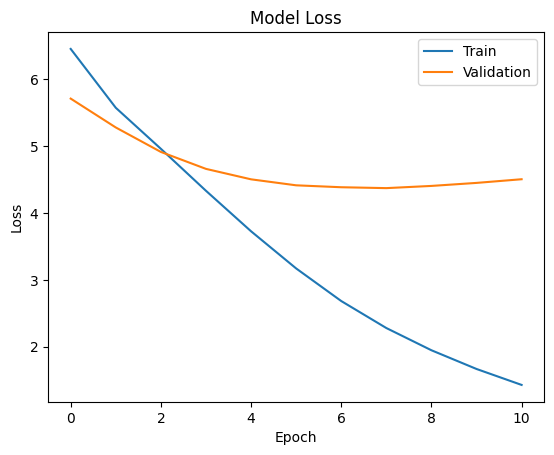

In [161]:
# interpretation graphs
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()